<a href="https://colab.research.google.com/github/suyash01-ggv/xray_image_classification/blob/main/xray_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import tensorflow

In [30]:
!ls drive/MyDrive/Deep learning

ls: cannot access 'drive/MyDrive/Deep': No such file or directory
ls: cannot access 'learning': No such file or directory


In [31]:
!ls drive/MyDrive

 1000140785.png
 1744021540894.jpg
'apaar id suyash.pdf'
 Btech_Students_CBDE.docx
'Chemistry allen'
 Classroom
'Colab Notebooks'
'collab extra files '
'Copy of 33a87cb2-259b-498f-abc9-53e04483631d-1_all_345.jpg'
'Deep learning'
'Final - Prototype - Proposal Submission Format CBDE_Rev1.docx (2).pdf (1).pdf'
'Getting started.pdf'
 IMG-20220915-WA0021.jpg
'IMG_20251219_094021_481 (1).jpg'
'IMG_20251219_094021_481 (2).jpg'
 IMG_20251219_094021_481.jpg
'Onboarding notes.gdoc'
 Physics
'Physics allen'
'resume.25 (1).pdf'
 resume.25.pdf
 Screenshot_20220915-143831.png
'Screenshot_20220922-155811 (1).png'
 Screenshot_20220922-155811.png
 Screenshot_20250716-172320.jpg
 Screenshot_20251111-133318.jpg
'shramsathi proposal final.pdf'
'Singapore India Hackathon 2026- suyash.pdf'
 Suyash
'suyashgupta IT 2024.pdf'
 Suyash_Gupta_Resume.pdf
'Untitled document (1).gdoc'
'Untitled document (2).gdoc'
'Untitled document.gdoc'
'Untitled folder'
'Untitled folder (1)'
'Untitled presentation.gslides'
'VID_20

In [32]:
!unzip drive/MyDrive/chest_xray-20250726T110654Z-1-001.zip

unzip:  cannot find or open drive/MyDrive/chest_xray-20250726T110654Z-1-001.zip, drive/MyDrive/chest_xray-20250726T110654Z-1-001.zip.zip or drive/MyDrive/chest_xray-20250726T110654Z-1-001.zip.ZIP.


In [33]:
print('Checking contents of Deep learning folder...')
!ls "drive/MyDrive/Deep learning"

Checking contents of Deep learning folder...
 cat.jpg				'image augmentation .ipynb'
 chest_xray-20250726T110654Z-1-001.zip	 Untitled
'CML+ANN - Churn Use case.ipynb'	 xray_image_classification.ipynb
'CNN : image Classification .ipynb'


In [34]:
!unzip "drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001.zip"

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1192-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1183-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1228-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1202-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1176-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1261-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1234-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1188-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1198-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1254-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1242-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1189-0001.jpeg  
  inflating: chest_xray/train

In [35]:
# lib
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [40]:
# setting the training data directory
DataDir =r"chest_xray/train/"

In [47]:
# initiallizing the category of classification
CATEGORIES =["NORMAL","PNEUMONIA"]

In [48]:
!ls chest_xray/test

NORMAL	PNEUMONIA


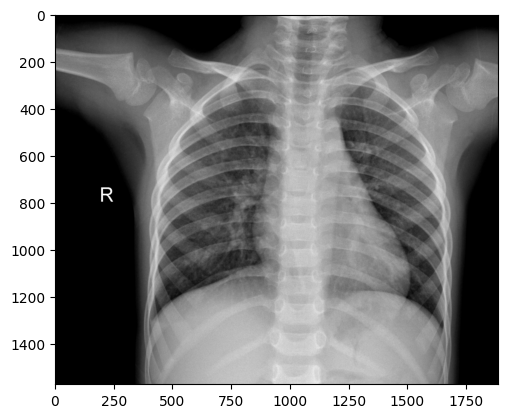

In [49]:
# converting the images into grayscale
for i in CATEGORIES:
    path = os.path.join(DataDir,i)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array,cmap='gray')
        plt.show()
        break
    break

In [50]:
# initializing the size of img so all img has same dimention
img_size = 100

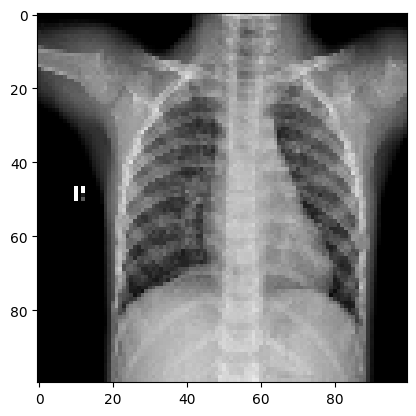

In [51]:
# image after resize and gray scale
new_array = cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [72]:
training_data=[]

In [73]:
# defining the function for training data according to the categories convertion the images into gray scale with resolution
# converting it into numpy arrays
def create_training_data():
  for i in CATEGORIES:
    path = os.path.join(DataDir,i)
    class_num = CATEGORIES.index(i)

    for img in os.listdir(path):
      try:
        img_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        new_array = cv2.resize(img_array,(img_size,img_size))
        training_data.append([new_array,class_num])
      except Exception as e:
        pass

In [74]:
create_training_data()

In [75]:
print(len(training_data))

5226


In [76]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
  print(sample)

[array([[174, 171, 167, ...,  14,  19,  24],
       [177, 172, 168, ...,  24,  26,  27],
       [146, 168, 160, ...,  18,  21,  23],
       ...,
       [ 23,  20,   5, ...,  30,  31,  31],
       [ 23,  21,   1, ...,  32,  30,  31],
       [ 23,  20,   2, ...,  34,  35,  35]], dtype=uint8), 1]
[array([[ 79,  81,  80, ..., 118, 116, 114],
       [ 78,  79,  81, ..., 120, 118, 117],
       [ 83,  87,  79, ..., 129, 132, 132],
       ...,
       [ 32,  16,  21, ...,  19,  19,  28],
       [ 41,  21,  21, ...,  19,  19,  30],
       [ 61,  20,  20, ...,  18,  21,  33]], dtype=uint8), 1]
[array([[  7,   5,   5, ...,  10,  18, 127],
       [  6,   5,   4, ...,   7,  12,  14],
       [  4,   3,   5, ...,   0,   0,   6],
       ...,
       [  9,   8,   6, ...,  11,  11,  12],
       [  9,   8,   6, ...,  11,  11,  12],
       [  9,   8,   6, ...,  11,  11,  11]], dtype=uint8), 1]
[array([[ 20,  37,  43, ...,   0,   0,   0],
       [ 14,  32,  42, ...,   0,   0,   0],
       [ 10,  22,  39, ...

In [77]:
X=[]
y=[]

In [78]:
# splitting the feature and labels
for features,labels in training_data:
  X.append(features)
  y.append(labels)

In [117]:
print(X[0].reshape(-1,img_size,img_size,1))

[[[[174]
   [171]
   [167]
   ...
   [ 14]
   [ 19]
   [ 24]]

  [[177]
   [172]
   [168]
   ...
   [ 24]
   [ 26]
   [ 27]]

  [[146]
   [168]
   [160]
   ...
   [ 18]
   [ 21]
   [ 23]]

  ...

  [[ 23]
   [ 20]
   [  5]
   ...
   [ 30]
   [ 31]
   [ 31]]

  [[ 23]
   [ 21]
   [  1]
   ...
   [ 32]
   [ 30]
   [ 31]]

  [[ 23]
   [ 20]
   [  2]
   ...
   [ 34]
   [ 35]
   [ 35]]]]


In [118]:
y =np.array(y)

In [119]:
# reshapping the features for making it compatible with tensorflow
X  = np.array(X).reshape(-1,img_size,img_size,1)

In [120]:
# as we do for training data similarly doing with validation data
validation_data=[]
DataDir_val =r"chest_xray/val/"

In [121]:
def create_validating_data():
  for i in CATEGORIES:
    path = os.path.join(DataDir_val,i)
    class_num = CATEGORIES.index(i)

    for img in os.listdir(path):
      try:
        img_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        new_array = cv2.resize(img_array,(img_size,img_size))
        validation_data.append([new_array,class_num])
      except Exception as e:
        pass

In [196]:
#DataDir_val =r"chest_xray/val/"
create_validating_data()

print(len(validation_data))

1040


In [197]:
import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
  print(sample)

[array([[  0,  20,  15, ...,  10,  14,  15],
       [239,  19,  15, ...,  12,  13,  14],
       [ 21,  18,  15, ...,  11,  14,  15],
       ...,
       [ 30,  33,  31, ...,  35,  32,  32],
       [ 32,  34,  29, ...,  35,  32,  27],
       [ 44,  33,  31, ...,  37,  30,  27]], dtype=uint8), 0]
[array([[ 13,  24,  31, ...,   0,   0,   0],
       [ 12,  24,  96, ...,   0,   0,   0],
       [ 11, 254, 163, ...,   0,   0,   0],
       ...,
       [  0,  19,  28, ...,   0,   0,   0],
       [  0,  20,  27, ...,   0,   0,   0],
       [  0,  18,  28, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[  8,  96,  46, ...,  19,  19,  14],
       [  1, 100,  80, ...,  26,  23,  16],
       [ 77,  73, 112, ...,  24,  20,  16],
       ...,
       [  0,   3,   7, ...,   0,   0,   0],
       [  0,   0,   6, ...,   0,   0,   0],
       [  1,   0,   0, ...,   0,   0,   0]], dtype=uint8), 0]
[array([[  0,  20,  15, ...,  10,  14,  15],
       [239,  19,  15, ...,  12,  13,  14],
       [ 21,  18,  15, ...

In [198]:
X_val=[]
y_val=[]

In [199]:
for features,labels in validation_data:
  X_val.append(features)
  y_val.append(labels)

In [200]:
y_val =np.array(y_val)
X_val  = np.array(X_val).reshape(-1,img_size,img_size,1)

In [201]:
# importing the library for train the mode and add the neural network layer

In [202]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten
import pickle

In [203]:
from keras.layers import Conv2D,MaxPooling2D

In [204]:
X = X/255.0
x_val =X_val/255.0

In [205]:
X.shape

(5226, 100, 100, 1)

In [206]:
x_val.shape

(1040, 100, 100, 1)

In [208]:
# intializing model
model= Sequential()

model.add(Conv2D(64,(3,3),input_shape=X.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(128,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(256,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(64))

model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation("sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [209]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [210]:
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

In [211]:
# fitting model with 10 epochs and using validation data we have created
model.fit(X,y,batch_size=4,epochs=10,validation_data=(x_val,y_val))

Epoch 1/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 322s 244ms/step - accuracy: 0.7426 - loss: 0.5800 - val_accuracy: 0.5000 - val_loss: 1.6197
Epoch 2/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 318s 243ms/step - accuracy: 0.7434 - loss: 0.5756 - val_accuracy: 0.5000 - val_loss: 1.2503
Epoch 3/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 316s 242ms/step - accuracy: 0.7434 - loss: 0.5729 - val_accuracy: 0.5000 - val_loss: 1.1548
Epoch 4/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 317s 242ms/step - accuracy: 0.7434 - loss: 0.5721 - val_accuracy: 0.5000 - val_loss: 1.1814
Epoch 5/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 321s 246ms/step - accuracy: 0.7434 - loss: 0.5717 - val_accuracy: 0.5000 - val_loss: 1.1839
Epoch 6/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 315s 241ms/step - accuracy: 0.7434 - loss: 0.5734 - val_accuracy: 0.5000 - val_loss: 1.1405
Epoch 7/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 311s 238ms/step - accuracy: 0.7434 - loss: 0.5723 - val_accuracy: 0.5000 - val_loss: 1.1253
Epoch 8/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 330s 244ms/step - ac

In [215]:
# saving model
model.save(r"model_10.h5")

In [217]:
# testing the model '

import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from keras.models import load_model

In [218]:
CATEGORIES =["NORMAL","PNEUMONIA"]


In [219]:
# function for preparing the image for prediction the class
def prepare(image):
  img_size =100
  # img_array = cv2.imread(image,cv2.IMREAD_GRAYSCALE )
  img = tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
  new_array = tf.keras.preprocessing.image.img_to_array(img)
  new_array = np.array(new_array).reshape(-1,img_size,img_size,1)

  return new_array.reshape(-1, img_size, img_size, 1)

In [221]:
import os
model = tf.keras.models.load_model(os.path.join(os.getcwd(), r"model_10.h5"))

In [224]:
image = r'chest_xray/test/NORMAL/NORMAL2-IM-0110-0001.jpeg'

In [225]:
prediction = model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[round(prediction[0][0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
[[0.86516196]]
1
PNEUMONIA


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=('Tensor(shape=(1, 100, 100, 1))',)
  warnings.warn(msg)


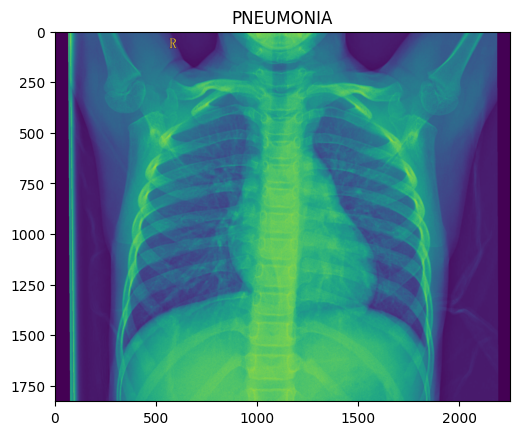

In [227]:
img = mpimg.imread(image)
implot=plt.imshow(img)
plt.title(CATEGORIES[round(prediction[0][0])])
plt.show()